<a href="https://colab.research.google.com/github/Giangysam/Sistemi/blob/main/Sistema_Lotto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Lottery Data Correlation Analysis

This notebook aims to analyze lottery extraction data to find correlations between numbers for each 'ruota' (lottery wheel).

### Step 1: Load the Data

To start, please provide the path to your lottery data file. Knowing the file format (e.g., CSV, TXT) will also help in loading it correctly.

Fill in the `file_path` and `file_format` variables in the code cell below.

In [ ]:
import pandas as pd

# Inserimento path da repository github
file_path = "https://github.com/Giangysam/Sistemi/raw/refs/heads/main/storico01_052026.txt"
file_format = "txt"

df = None
# Gestione specifica per file TXT con separazione tramite spazi e senza intestazione
if file_format.lower() == 'txt':
    try:
        # Usiamo header=None per indicare che non c'è una riga di intestazione
        # Usiamo sep='\s+' per gestire uno o più spazi come delimitatore
        # Usiamo engine='python' perché sep accetta una regex
        df = pd.read_csv(file_path, sep='\s+', header=None, engine='python')
        # Assegniamo nomi significativi alle colonne
        df.columns = ['Data', 'Ruota', 'Numero_1', 'Numero_2', 'Numero_3', 'Numero_4', 'Numero_5']
    except Exception as e:
        print(f"Si è verificato un errore durante la lettura del file TXT: {e}")
elif file_format.lower() == 'csv':
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"Errore: File non trovato in {file_path}. Controlla il percorso.")
    except Exception as e:
        print(f"Si è verificato un errore durante la lettura del file CSV: {e}")
elif file_format.lower() == 'excel':
    try:
        df = pd.read_excel(file_path)
    except FileNotFoundError:
        print(f"Errore: File non trovato in {file_path}. Controlla il percorso.")
    except Exception as e:
        print(f"Si è verificato un errore durante la lettura del file Excel: {e}")
else:
    print(f"Formato file non supportato: {file_format}. Fornisci un file 'csv', 'txt' o 'excel'.")


if df is not None:
    print(f"Dati caricati con successo da {file_path}.")
    display(df.head())
    print(f"\nInformazioni sul DataFrame:")
    df.info()

<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_645/3414786491.py:14: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(file_path, sep='\s+', header=None, engine='python')


Dati caricati con successo da https://github.com/Giangysam/Sistemi/raw/refs/heads/main/storico01_052026.txt.


,Data,Ruota,Numero_1,Numero_2,Numero_3,Numero_4,Numero_5
0,2001/01/03,BA,26,59,60,67,17
1,2001/01/03,CA,13,83,16,41,68
2,2001/01/03,FI,33,87,76,7,10
3,2001/01/03,GE,5,38,3,65,72
4,2001/01/03,MI,62,30,7,61,52



Informazioni sul DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41452 entries, 0 to 41451
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Data      41452 non-null  object
 1   Ruota     37642 non-null  object
 2   Numero_1  41452 non-null  int64 
 3   Numero_2  41452 non-null  int64 
 4   Numero_3  41452 non-null  int64 
 5   Numero_4  41452 non-null  int64 
 6   Numero_5  41452 non-null  int64 
dtypes: int64(5), object(2)
memory usage: 2.2+ MB


### Passo 2: Analisi della Frequenza dei Numeri per Ruota

Ora che i dati sono caricati correttamente, possiamo calcolare la frequenza di estrazione di ogni numero per ciascuna 'Ruota'.

In [ ]:
# 1. Pulizia Dati: Rimozione delle righe con 'Ruota' mancante
df_cleaned = df.dropna(subset=['Ruota']).copy()

# 2. Rimodellamento Dati (Melt): Trasformiamo i numeri in un'unica colonna
# Selezioniamo solo le colonne rilevanti per il melt
numbers_columns = ['Numero_1', 'Numero_2', 'Numero_3', 'Numero_4', 'Numero_5']
df_melted = df_cleaned.melt(id_vars=['Data', 'Ruota'], value_vars=numbers_columns, var_name='Posizione_Estrazione', value_name='Numero')

# 3. Calcolo della Frequenza
# Raggruppiamo per 'Ruota' e 'Numero' e contiamo le occorrenze
frequenze_per_ruota = df_melted.groupby(['Ruota', 'Numero']).size().reset_index(name='Frequenza')

# Ordiniamo le frequenze in ordine decrescente per numero di estrazioni all'interno di ogni ruota
frequenze_per_ruota_sorted = frequenze_per_ruota.sort_values(by=['Ruota', 'Frequenza'], ascending=[True, False])

# 4. Visualizzazione
print("Frequenza di estrazione di ogni numero per ruota (ordinato per frequenza decrescente):\n")

# Possiamo visualizzare le top N frequenze per ogni ruota, o tutte
# Per esempio, mostriamo le prime 10 estrazioni più frequenti per ogni ruota
for ruota in frequenze_per_ruota_sorted['Ruota'].unique():
    print(f"--- Ruota: {ruota} ---")
    display(frequenze_per_ruota_sorted[frequenze_per_ruota_sorted['Ruota'] == ruota].head(10))
    print("\n")

# Per visualizzare la frequenza di tutti i numeri per ruota:
# display(frequenze_per_ruota_sorted)


Frequenza di estrazione di ogni numero per ruota (ordinato per frequenza decrescente):

--- Ruota: BA ---


,Ruota,Numero,Frequenza
47,BA,48,243
65,BA,66,243
46,BA,47,242
2,BA,3,237
19,BA,20,235
60,BA,61,235
80,BA,81,234
59,BA,60,233
9,BA,10,232
7,BA,8,231




--- Ruota: CA ---


,Ruota,Numero,Frequenza
90,CA,1,248
145,CA,56,245
159,CA,70,244
95,CA,6,237
140,CA,51,234
162,CA,73,233
109,CA,20,230
170,CA,81,230
173,CA,84,230
169,CA,80,229




--- Ruota: FI ---


...

,Ruota,Numero,Frequenza
709,RN,80,220
675,RN,46,217
667,RN,38,215
651,RN,22,210
656,RN,27,208
662,RN,33,208
638,RN,9,207
646,RN,17,207
645,RN,16,206
639,RN,10,205




--- Ruota: TO ---


,Ruota,Numero,Frequenza
761,TO,42,252
745,TO,26,241
765,TO,46,238
804,TO,85,238
807,TO,88,238
770,TO,51,233
795,TO,76,232
720,TO,1,231
757,TO,38,228
724,TO,5,227




--- Ruota: VE ---


,Ruota,Numero,Frequenza
862,VE,53,248
843,VE,34,245
827,VE,18,240
831,VE,22,240
883,VE,74,239
854,VE,45,232
887,VE,78,232
898,VE,89,232
846,VE,37,230
865,VE,56,230


### Passo 3: Calcolo e Visualizzazione della Co-occorrenza tra i Numeri per Ruota

Procediamo ora con il calcolo e la visualizzazione della frequenza con cui i numeri appaiono insieme in ogni estrazione per ciascuna ruota. Questo ci darà un'idea delle 'correlazioni' tra i numeri.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

# 1. Preparazione Dati: Raggruppiamo i numeri estratti per ogni estrazione e ruota
# Otteniamo una lista di numeri per ogni combinazione (Data, Ruota)
grouped_draws = df_melted.groupby(['Data', 'Ruota'])['Numero'].apply(list)

# Inizializziamo un dizionario per memorizzare le matrici di co-occorrenza per ogni ruota
co_occurrence_matrices = {}

# Iteriamo attraverso ogni ruota unica
for ruota in df_cleaned['Ruota'].unique():
    print(f"Elaborazione della Ruota: {ruota}...")
    # Filtriamo le estrazioni per la ruota corrente
    # Usiamo .loc per accedere a gruppi specifici, con slice(None) per tutte le date
    ruota_specific_draws = grouped_draws.loc[(slice(None), ruota)]

    # Inizializziamo una matrice 90x90 riempita di zeri per le co-occorrenze
    # I numeri del lotto vanno da 1 a 90
    co_occurrence_matrix = pd.DataFrame(0, index=range(1, 91), columns=range(1, 91))

    # Per ogni estrazione della ruota corrente
    for draw_numbers in ruota_specific_draws:
        # Convertiamo in set per rimuovere duplicati (anche se nel lotto non dovrebbero esserci)
        # e poi ordiniamo per garantire che (a,b) e (b,a) siano trattati allo stesso modo
        unique_numbers_in_draw = sorted(list(set(draw_numbers)))

        # Generiamo tutte le coppie uniche di numeri all'interno dell'estrazione
        for num1, num2 in itertools.combinations(unique_numbers_in_draw, 2):
            # Incrementiamo il conteggio della co-occorrenza per la coppia
            co_occurrence_matrix.loc[num1, num2] += 1
            co_occurrence_matrix.loc[num2, num1] += 1 # La matrice è simmetrica

    # Salviamo la matrice di co-occorrenza per la ruota
    co_occurrence_matrices[ruota] = co_occurrence_matrix

print("Calcolo delle matrici di co-occorrenza completato.")

Elaborazione della Ruota: BA...
Elaborazione della Ruota: CA...
Elaborazione della Ruota: FI...
Elaborazione della Ruota: GE...
Elaborazione della Ruota: MI...
Elaborazione della Ruota: PA...
Elaborazione della Ruota: RM...
Elaborazione della Ruota: TO...
Elaborazione della Ruota: VE...
Elaborazione della Ruota: RN...
Calcolo delle matrici di co-occorrenza completato.


### Visualizzazione delle Matrici di Co-occorrenza

Ora visualizziamo le matrici di co-occorrenza usando delle heatmap. Ogni grafico mostrerà quanto frequentemente due numeri sono stati estratti insieme per una specifica ruota. Data la quantità di ruote, verranno generati molti grafici.

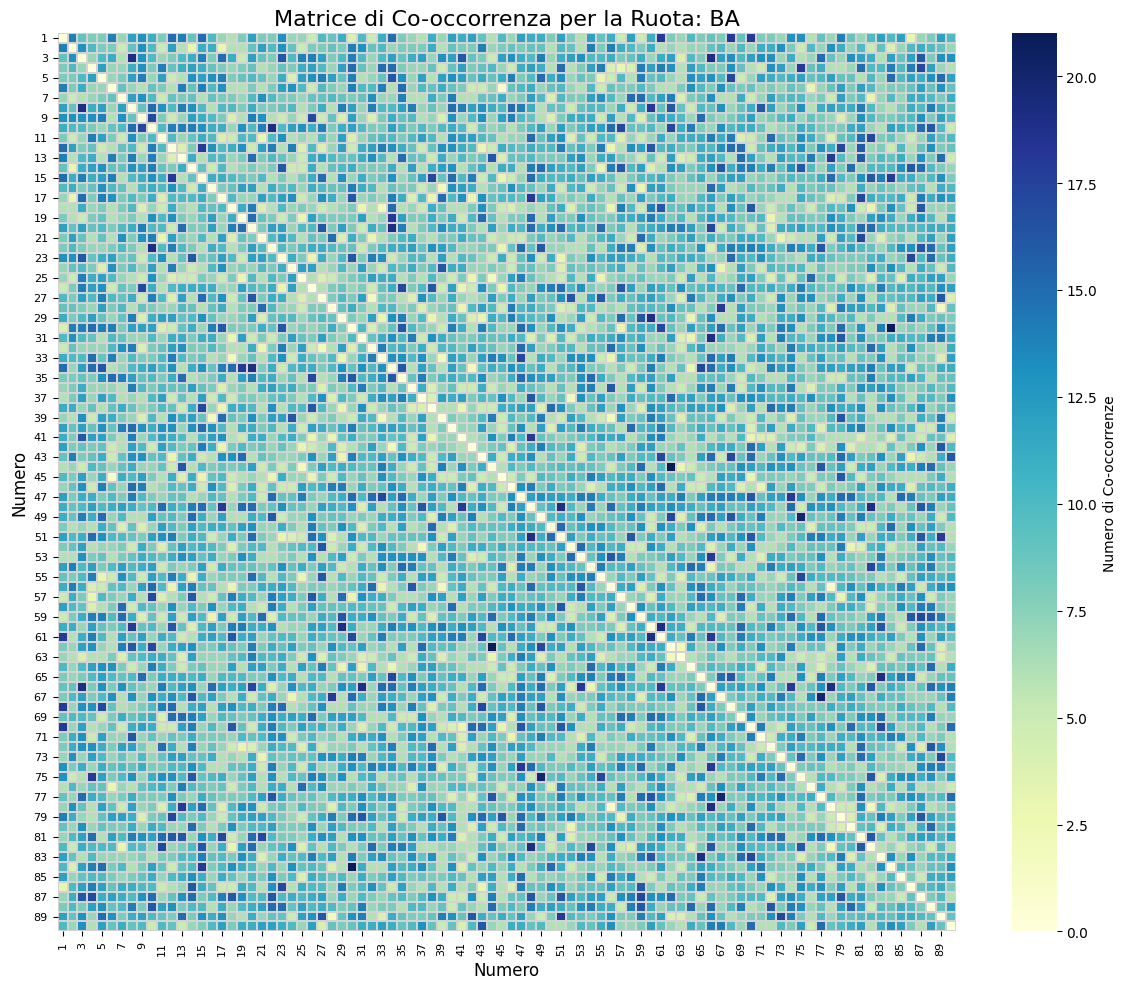

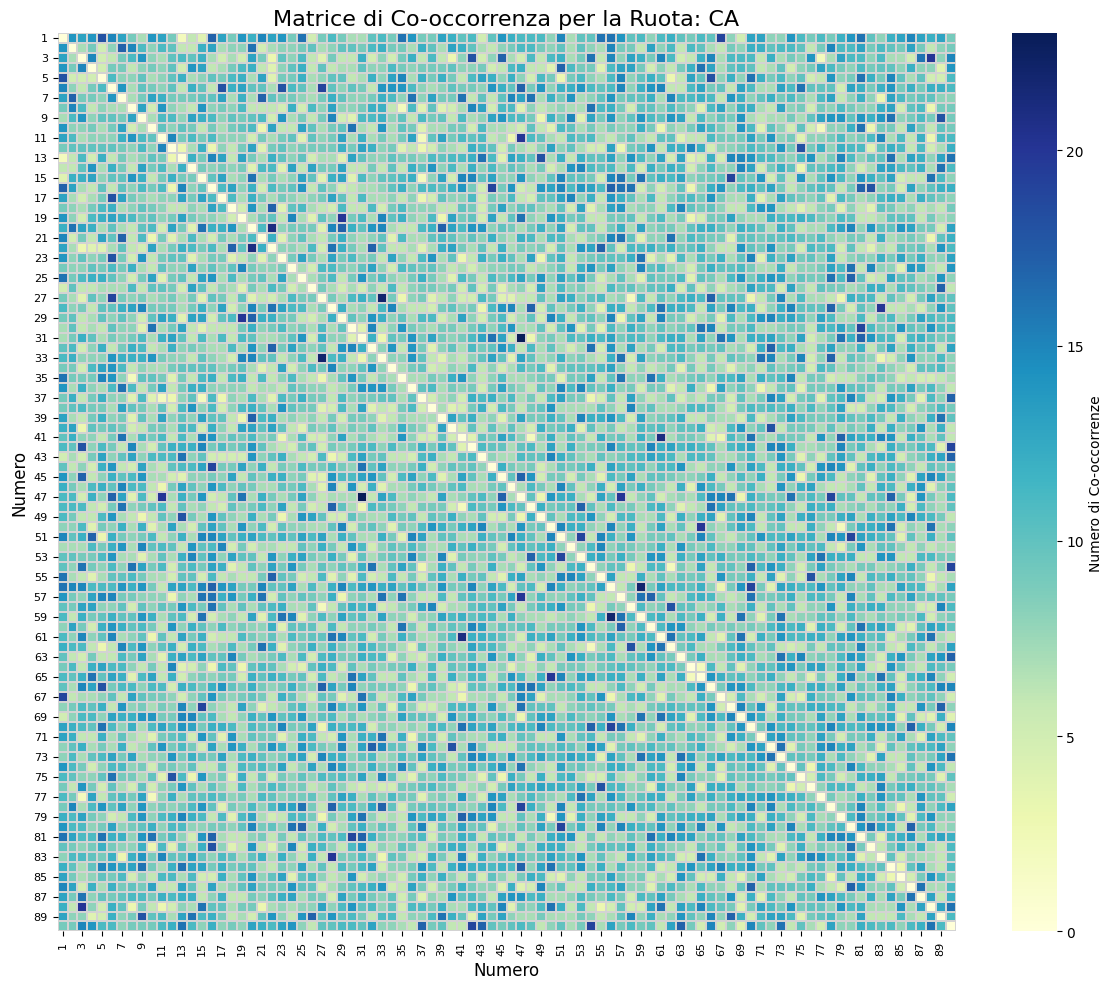

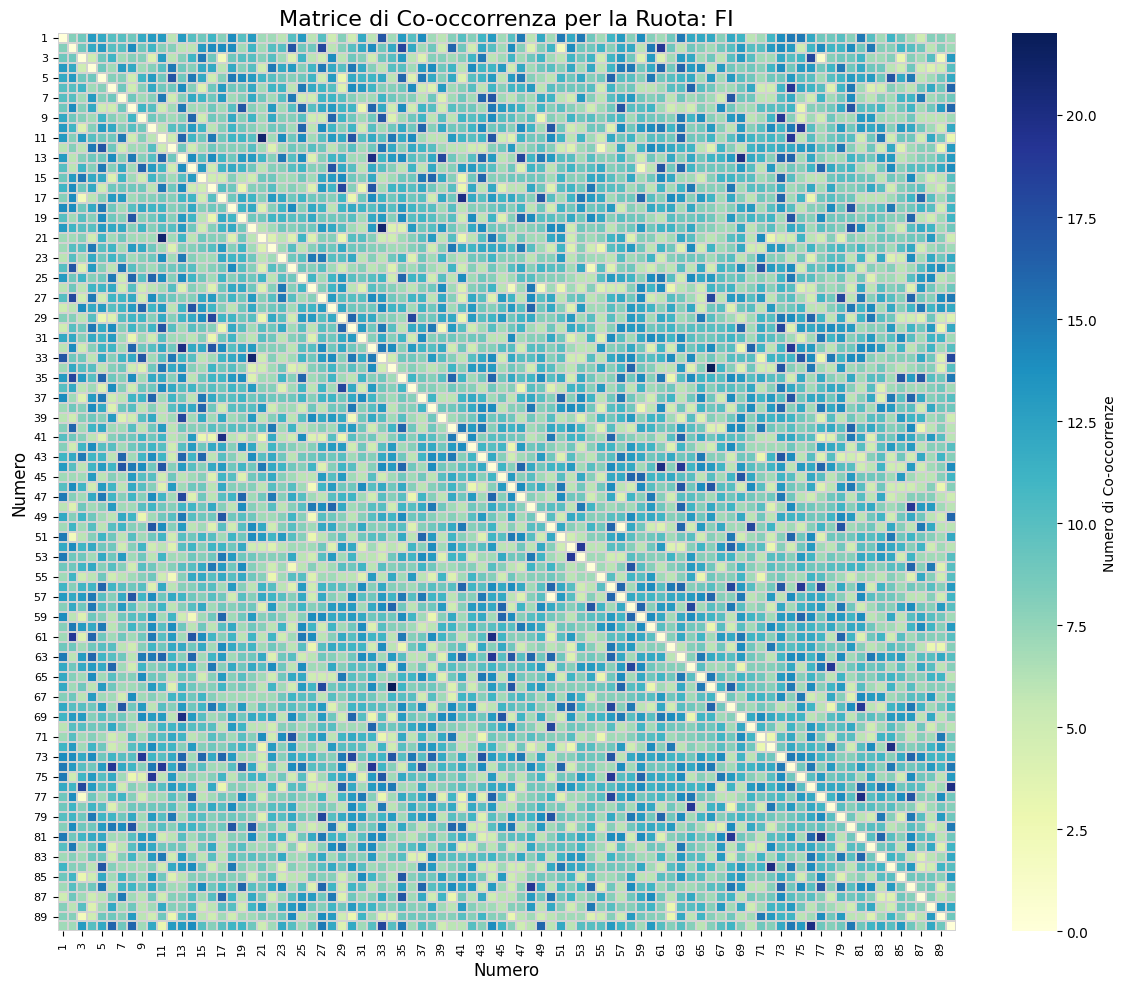

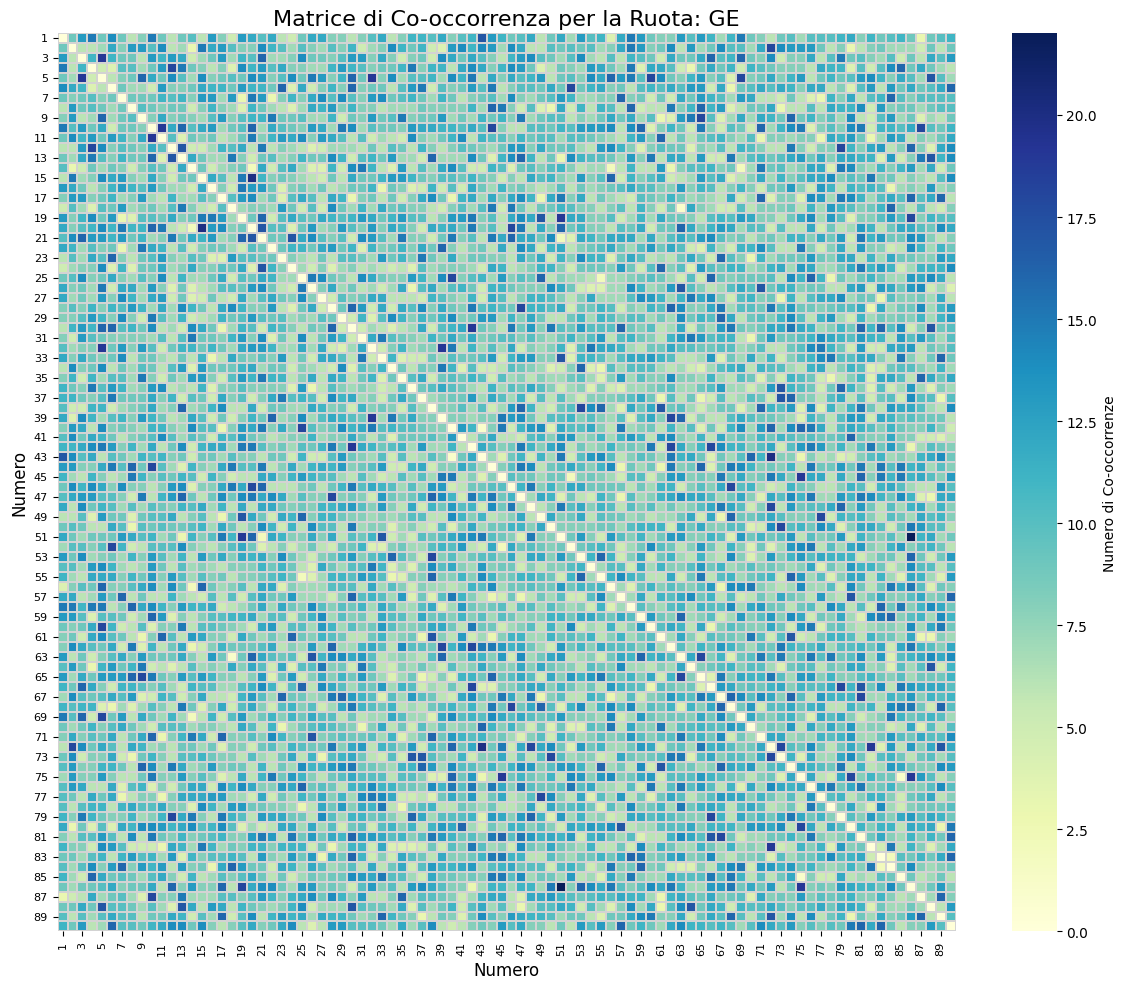

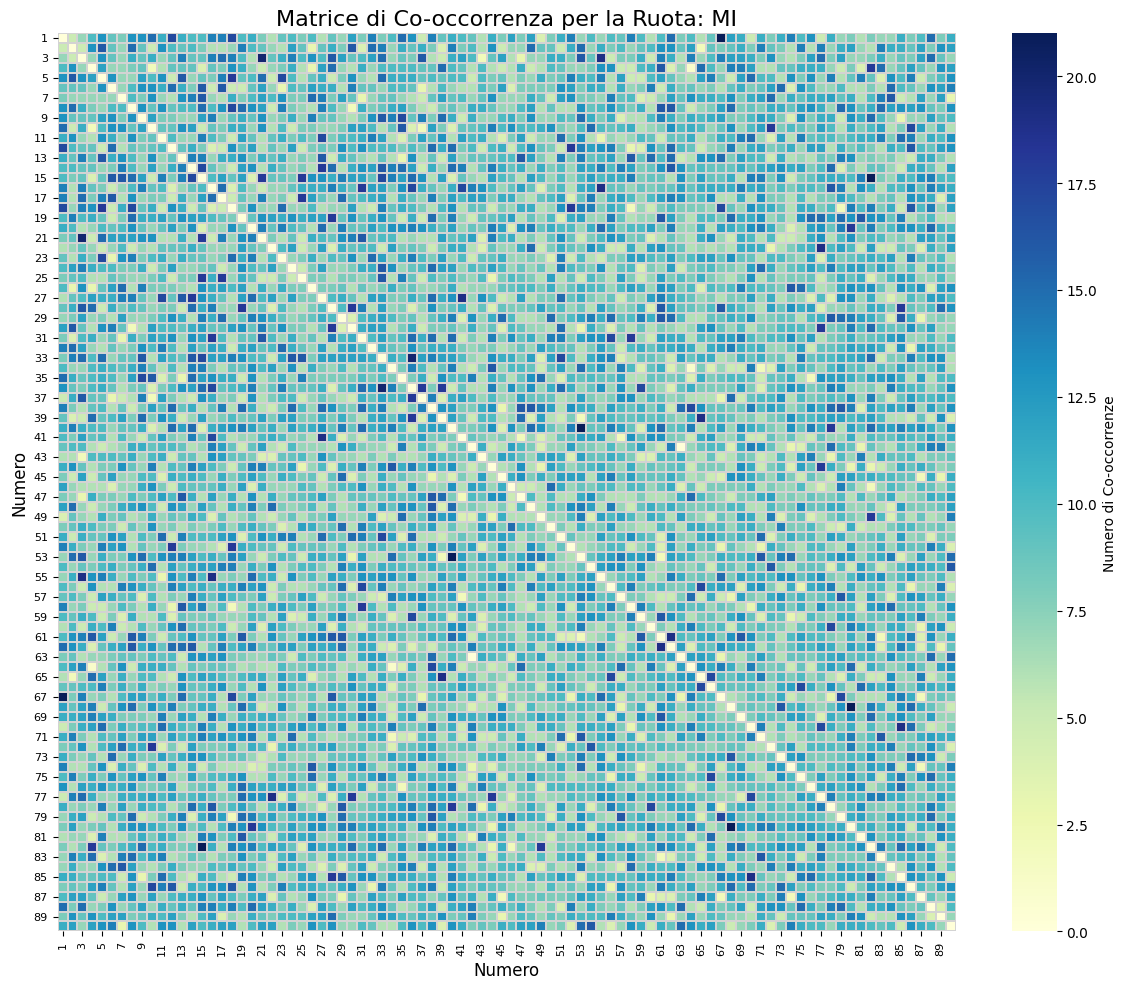

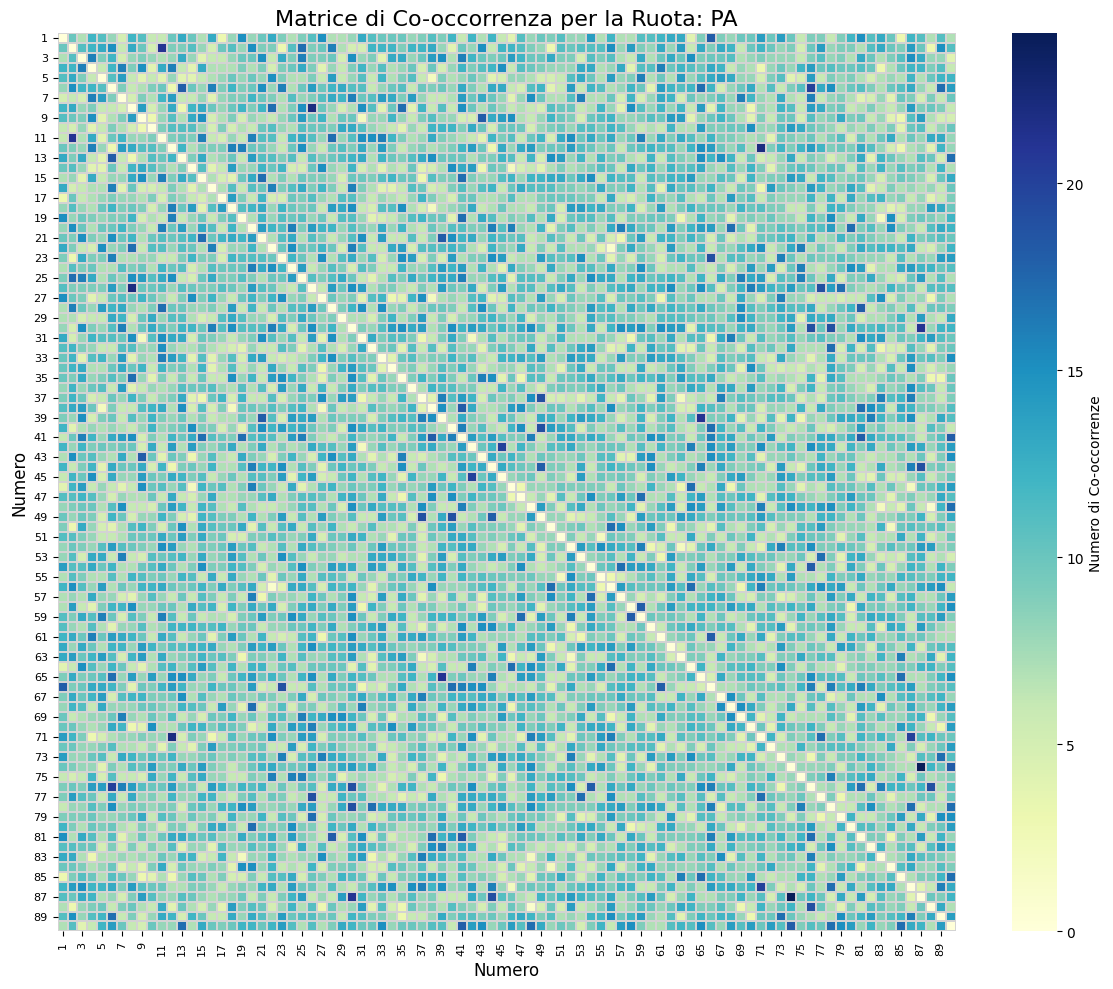

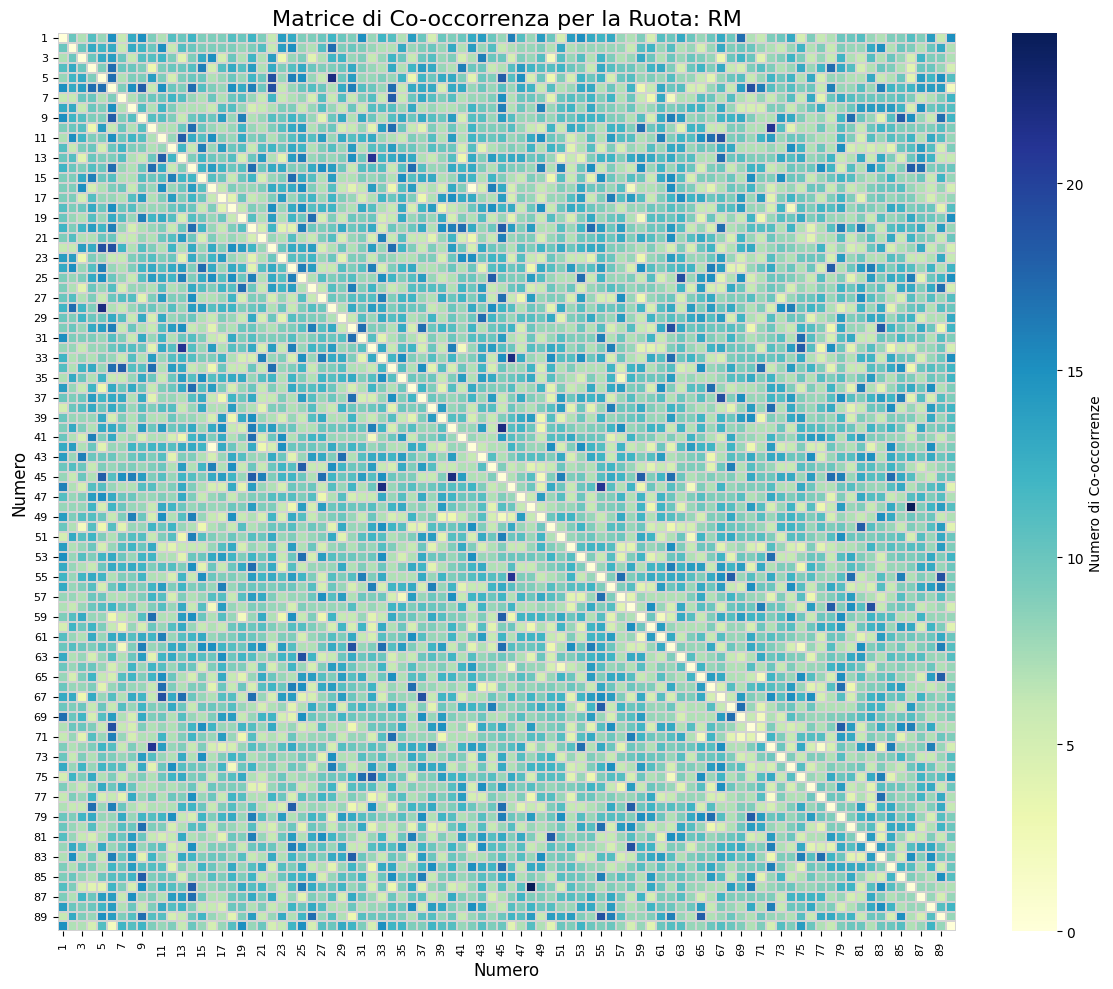

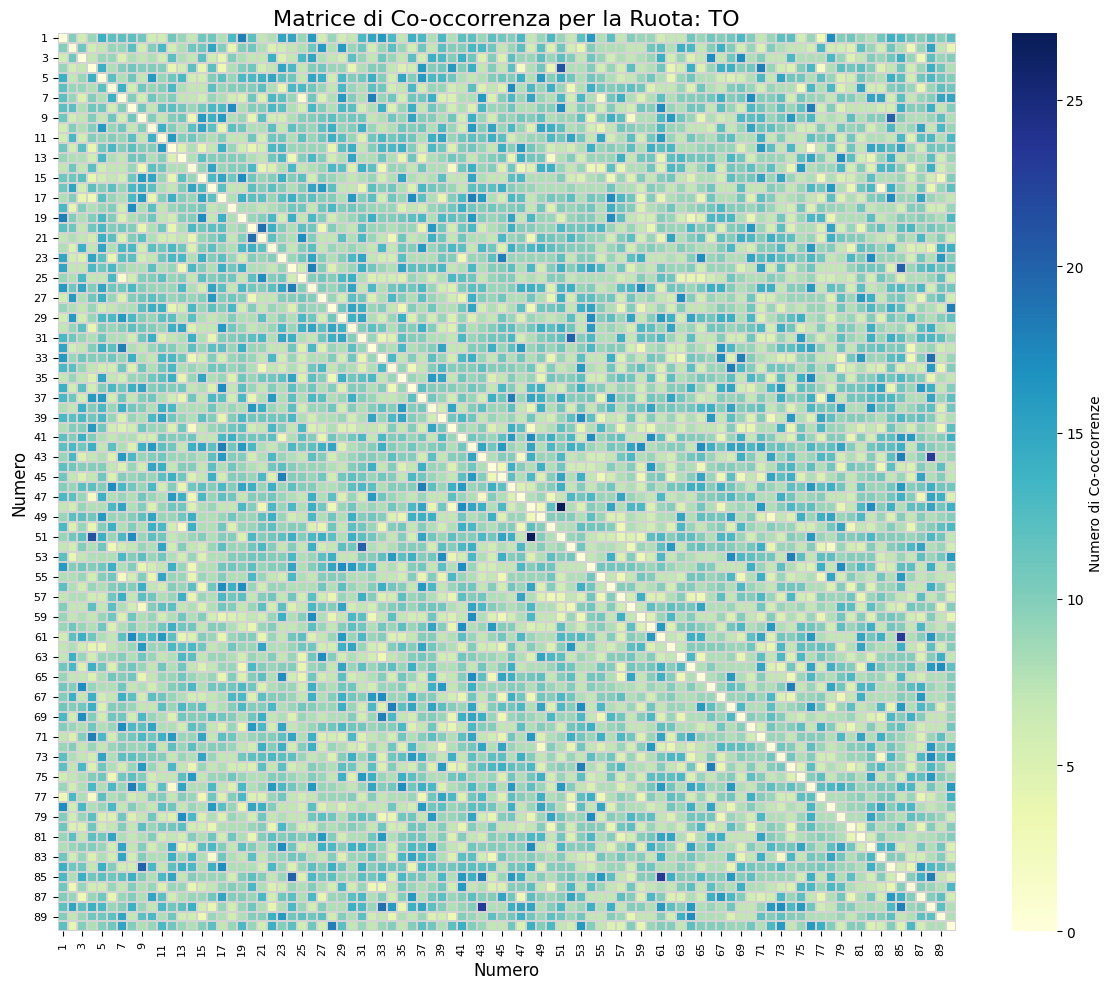

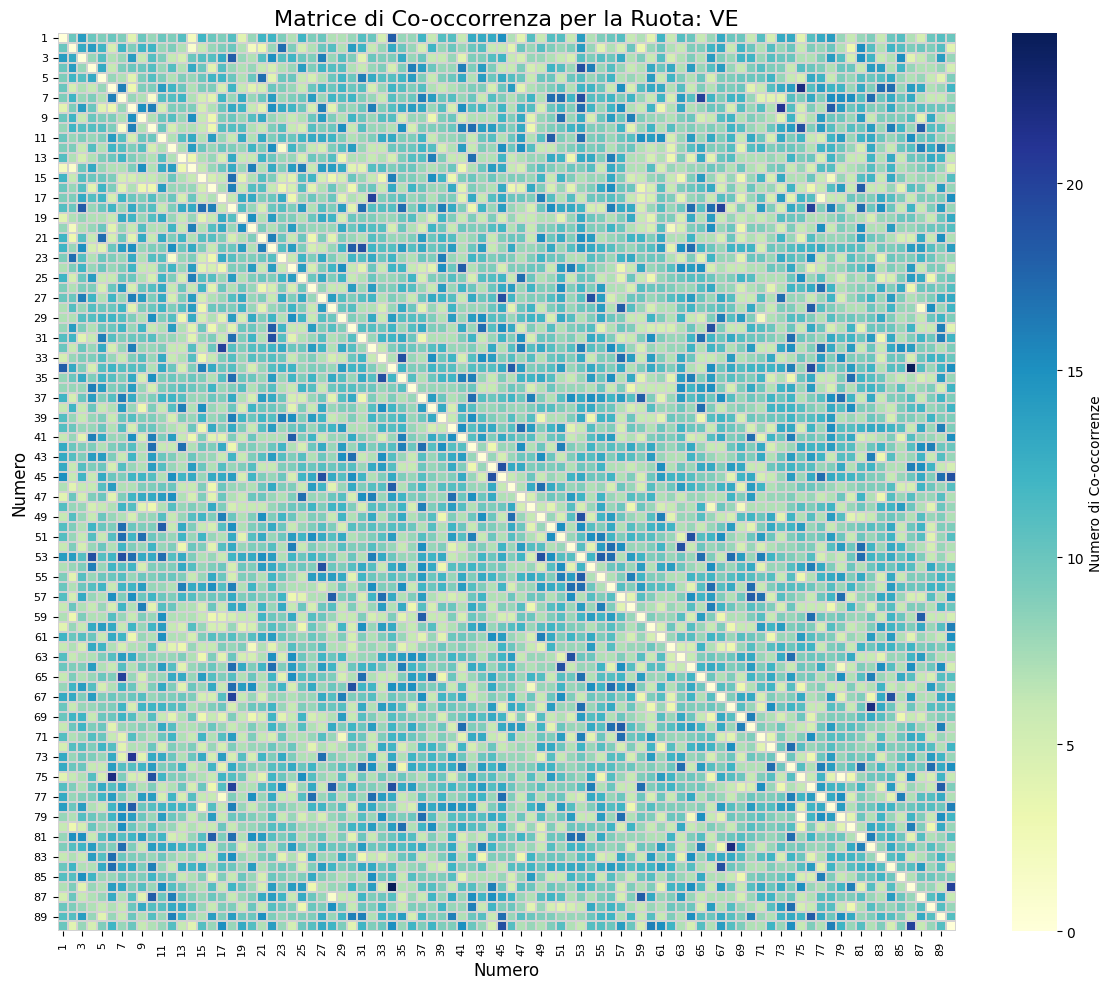

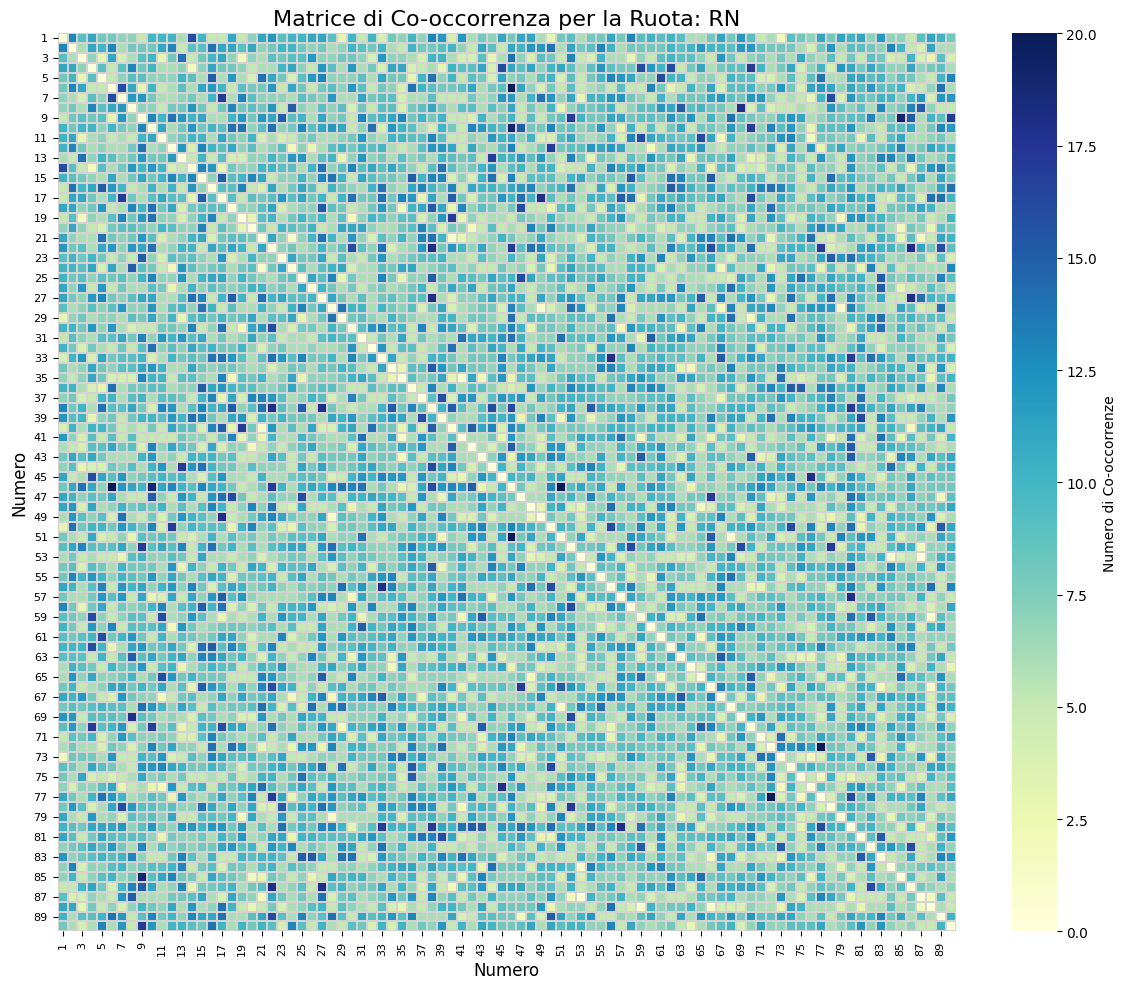

Visualizzazione delle matrici di co-occorrenza completata.


In [ ]:
for ruota, matrix in co_occurrence_matrices.items():
    plt.figure(figsize=(12, 10))
    # Usiamo un cmap (colormaps) per visualizzare l'intensità della co-occorrenza
    # annot=False per evitare di sovraccaricare il grafico con i numeri se la matrice è grande
    # fmt='d' per formattare i numeri come interi
    sns.heatmap(matrix, cmap='YlGnBu', annot=False, fmt='d', linewidths=0.1, linecolor='lightgray', cbar_kws={'label': 'Numero di Co-occorrenze'})
    plt.title(f'Matrice di Co-occorrenza per la Ruota: {ruota}', fontsize=16)
    plt.xlabel('Numero', fontsize=12)
    plt.ylabel('Numero', fontsize=12)
    plt.xticks(rotation=90, ha='center', fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout() # Adatta i margini per evitare sovrapposizioni
    plt.show()

print("Visualizzazione delle matrici di co-occorrenza completata.")

Fase di pulizia dei dati

### Top 5 Numeri più Frequenti per Ogni Ruota

Di seguito sono riportati i 5 numeri con la più alta frequenza di estrazione per ciascuna 'ruota', insieme alla loro frequenza.

In [ ]:
# Iteriamo attraverso ogni ruota unica nel DataFrame ordinato
for ruota in frequenze_per_ruota_sorted['Ruota'].unique():
    print(f"--- Ruota: {ruota} ---")
    # Filtriamo il DataFrame per la ruota corrente e mostriamo i primi 5 numeri
    top_5_numbers = frequenze_per_ruota_sorted[frequenze_per_ruota_sorted['Ruota'] == ruota].head(5)
    display(top_5_numbers)
    print("\n")

--- Ruota: BA ---


,Ruota,Numero,Frequenza
47,BA,48,243
65,BA,66,243
46,BA,47,242
2,BA,3,237
19,BA,20,235




--- Ruota: CA ---


,Ruota,Numero,Frequenza
90,CA,1,248
145,CA,56,245
159,CA,70,244
95,CA,6,237
140,CA,51,234




--- Ruota: FI ---


...

,Ruota,Numero,Frequenza
709,RN,80,220
675,RN,46,217
667,RN,38,215
651,RN,22,210
656,RN,27,208




--- Ruota: TO ---


,Ruota,Numero,Frequenza
761,TO,42,252
745,TO,26,241
765,TO,46,238
804,TO,85,238
807,TO,88,238




--- Ruota: VE ---


,Ruota,Numero,Frequenza
862,VE,53,248
843,VE,34,245
827,VE,18,240
831,VE,22,240
883,VE,74,239


### Passo 4: Analisi delle Terzine (Triplette) di Numeri con Maggiore Co-occorrenza

Ora estenderemo l'analisi per identificare le terzine di numeri che appaiono con maggiore frequenza nella stessa estrazione per ogni 'ruota'. Questo ci darà un'idea delle combinazioni di tre numeri più 'forti'.

In [ ]:
import itertools

# Inizializziamo un dizionario per memorizzare le frequenze delle terzine per ogni ruota
triplet_frequencies = {}

# Iteriamo attraverso ogni ruota unica
for ruota in df_cleaned['Ruota'].unique():
    print(f"Calcolo delle terzine per la Ruota: {ruota}...")
    # Filtriamo le estrazioni per la ruota corrente
    ruota_specific_draws = grouped_draws.loc[(slice(None), ruota)]

    # Dizionario temporaneo per contare le terzine per la ruota attuale
    current_ruota_triplets = {}

    # Per ogni estrazione della ruota corrente
    for draw_numbers in ruota_specific_draws:
        unique_numbers_in_draw = sorted(list(set(draw_numbers)))

        # Generiamo tutte le combinazioni di 3 numeri (terzine) all'interno dell'estrazione
        for triplet in itertools.combinations(unique_numbers_in_draw, 3):
            # Usiamo la tupla ordinata come chiave per garantire l'univocità
            triplet_key = tuple(sorted(triplet))
            current_ruota_triplets[triplet_key] = current_ruota_triplets.get(triplet_key, 0) + 1

    # Convertiamo il dizionario in un DataFrame per facilitare l'ordinamento e la visualizzazione
    if current_ruota_triplets:
        triplet_df = pd.DataFrame(list(current_ruota_triplets.items()), columns=['Terzina', 'Frequenza'])
        triplet_df = triplet_df.sort_values(by='Frequenza', ascending=False).reset_index(drop=True)
        triplet_frequencies[ruota] = triplet_df
    else:
        triplet_frequencies[ruota] = pd.DataFrame(columns=['Terzina', 'Frequenza'])

print("Calcolo delle frequenze delle terzine completato.")

Calcolo delle terzine per la Ruota: BA...
Calcolo delle terzine per la Ruota: CA...
Calcolo delle terzine per la Ruota: FI...
Calcolo delle terzine per la Ruota: GE...
Calcolo delle terzine per la Ruota: MI...
Calcolo delle terzine per la Ruota: PA...
Calcolo delle terzine per la Ruota: RM...
Calcolo delle terzine per la Ruota: TO...
Calcolo delle terzine per la Ruota: VE...
Calcolo delle terzine per la Ruota: RN...
Calcolo delle frequenze delle terzine completato.


### Top 5 Terzine (Triplette) più Frequenti per Ogni Ruota

Di seguito sono riportate le 5 terzine con la più alta frequenza di estrazione per ciascuna 'ruota', insieme alla loro frequenza.

In [ ]:
# Visualizziamo le top 5 terzine per ogni ruota
for ruota, df_triplets in triplet_frequencies.items():
    print(f"--- Ruota: {ruota} ---")
    if not df_triplets.empty:
        display(df_triplets.head(5))
    else:
        print("Nessuna terzina trovata per questa ruota.")
    print("\n")

--- Ruota: BA ---


,Terzina,Frequenza
0,"(21, 23, 56)",5
1,"(15, 16, 40)",5
2,"(8, 60, 78)",4
3,"(38, 47, 80)",4
4,"(1, 62, 79)",4




--- Ruota: CA ---


,Terzina,Frequenza
0,"(32, 42, 90)",5
1,"(44, 56, 70)",5
2,"(31, 47, 55)",4
3,"(30, 81, 85)",4
4,"(20, 32, 67)",4




--- Ruota: FI ---


...

,Terzina,Frequenza
0,"(26, 49, 78)",5
1,"(61, 65, 85)",5
2,"(1, 50, 90)",5
3,"(4, 42, 52)",5
4,"(13, 59, 79)",5




--- Ruota: VE ---


,Terzina,Frequenza
0,"(37, 42, 59)",5
1,"(10, 84, 87)",5
2,"(12, 25, 87)",5
3,"(15, 38, 65)",5
4,"(7, 67, 84)",5




--- Ruota: RN ---


,Terzina,Frequenza
0,"(13, 47, 81)",4
1,"(4, 43, 45)",4
2,"(8, 61, 62)",4
3,"(38, 54, 87)",4
4,"(3, 46, 75)",4


### Frequenza delle Terzine (Triplette) considerando Tutte le Ruote Insieme

Ora calcoliamo la frequenza di tutte le terzine estraibili, aggregando i dati da tutte le 'ruote'. Questo ci darà una visione delle combinazioni di tre numeri più frequenti a livello generale.

In [ ]:
import itertools

# Dizionario per memorizzare le frequenze delle terzine a livello globale
global_triplet_frequencies = {}

# Iteriamo attraverso tutte le estrazioni raggruppate (Data, Ruota)
for _, draw_numbers in grouped_draws.items():
    unique_numbers_in_draw = sorted(list(set(draw_numbers)))

    # Generiamo tutte le combinazioni di 3 numeri (terzine) all'interno dell'estrazione
    for triplet in itertools.combinations(unique_numbers_in_draw, 3):
        # Usiamo la tupla ordinata come chiave per garantire l'univocità
        triplet_key = tuple(sorted(triplet))
        global_triplet_frequencies[triplet_key] = global_triplet_frequencies.get(triplet_key, 0) + 1

# Convertiamo il dizionario in un DataFrame per facilitare l'ordinamento e la visualizzazione
if global_triplet_frequencies:
    global_triplet_df = pd.DataFrame(list(global_triplet_frequencies.items()), columns=['Terzina', 'Frequenza'])
    global_triplet_df = global_triplet_df.sort_values(by='Frequenza', ascending=False).reset_index(drop=True)
    print("Calcolo delle frequenze delle terzine globali completato.")
    display(global_triplet_df.head(10))
else:
    print("Nessuna terzina trovata nell'analisi globale.")

Calcolo delle frequenze delle terzine globali completato.


,Terzina,Frequenza
0,"(7, 67, 84)",13
1,"(8, 32, 40)",13
2,"(10, 11, 44)",13
3,"(10, 11, 65)",13
4,"(27, 64, 89)",12
5,"(18, 64, 78)",12
6,"(1, 57, 69)",12
7,"(20, 54, 90)",12
8,"(5, 39, 57)",12
9,"(61, 63, 66)",12


### Visualizzazione delle 10 Terzine Globali più Frequenti

Questo grafico a barre mostra le 10 terzine di numeri che sono state estratte con la maggiore frequenza, considerando tutte le 'ruote' insieme.

/tmp/ipykernel_645/2894528559.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Terzina_Str', y='Frequenza', data=top_10_global_triplets, palette='viridis')


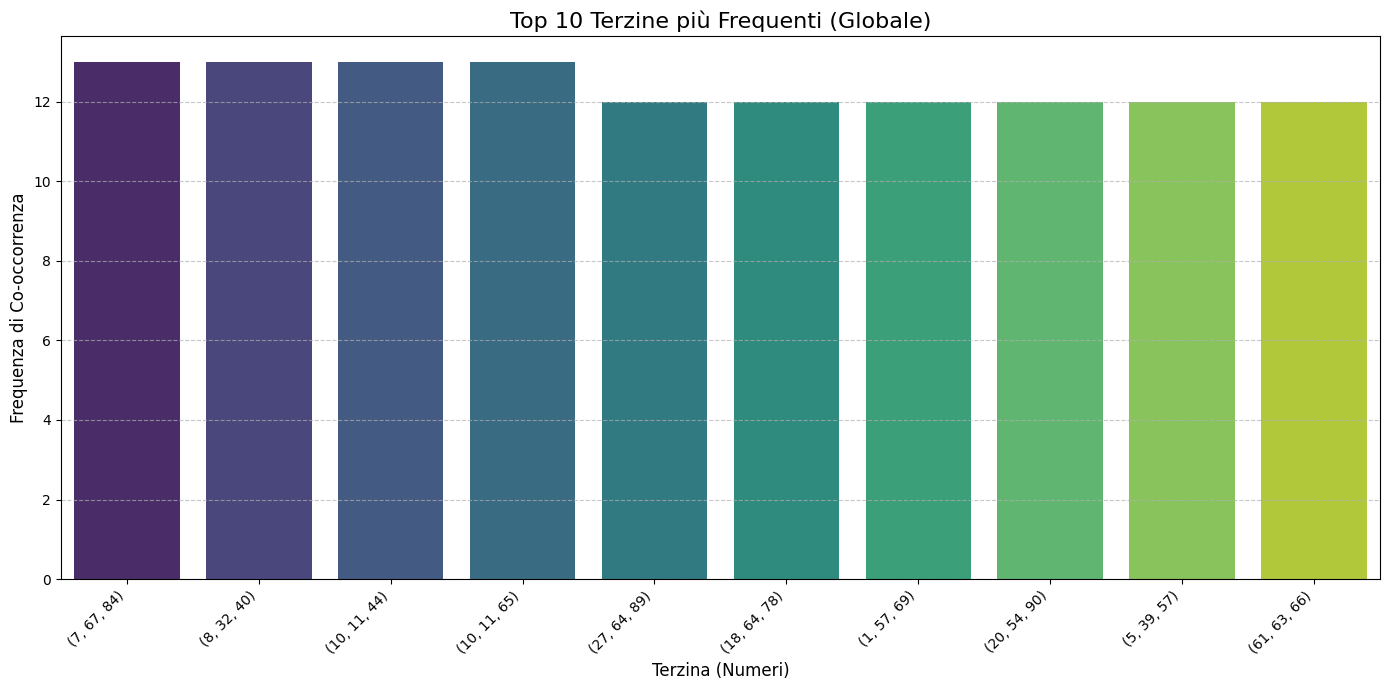

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prendiamo le prime 10 terzine globali
top_10_global_triplets = global_triplet_df.head(10).copy() # Aggiunto .copy() per evitare SettingWithCopyWarning

# Convertiamo le tuple delle terzine in stringhe per l'asse X del grafico
top_10_global_triplets['Terzina_Str'] = top_10_global_triplets['Terzina'].apply(lambda x: str(x))

plt.figure(figsize=(14, 7))
sns.barplot(x='Terzina_Str', y='Frequenza', data=top_10_global_triplets, palette='viridis')
plt.title('Top 10 Terzine più Frequenti (Globale)', fontsize=16)
plt.xlabel('Terzina (Numeri)', fontsize=12)
plt.ylabel('Frequenza di Co-occorrenza', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10) # Ruota le etichette per leggibilità
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Assicura che tutto si adatti bene al layout
plt.show()

### Analisi della Correlazione Temporale delle Terzine

Per analizzare una potenziale correlazione temporale, dobbiamo esaminare quando le terzine più frequenti sono state estratte nel corso del tempo. A tale scopo, creeremo un nuovo DataFrame che registra ogni singola occorrenza di una terzina insieme alla data e alla ruota di estrazione.

In [ ]:
import pandas as pd
import itertools

# Create a list to store triplet occurrences with their dates
temporal_triplet_occurrences = []

# Iterate through all grouped draws (Data, Ruota)
for (data, ruota), draw_numbers in grouped_draws.items():
    unique_numbers_in_draw = sorted(list(set(draw_numbers)))
    # Generate all combinations of 3 numbers (triplets) within the draw
    for triplet in itertools.combinations(unique_numbers_in_draw, 3):
        temporal_triplet_occurrences.append({'Data': data, 'Ruota': ruota, 'Terzina': tuple(sorted(triplet))})

temporal_triplet_df = pd.DataFrame(temporal_triplet_occurrences)

# Convert 'Data' column to datetime objects for time-series analysis
temporal_triplet_df['Data'] = pd.to_datetime(temporal_triplet_df['Data'])

print("DataFrame delle occorrenze temporali delle terzine creato:")
display(temporal_triplet_df.head())

DataFrame delle occorrenze temporali delle terzine creato:


,Data,Ruota,Terzina
0,2001-01-03,BA,"(17, 26, 59)"
1,2001-01-03,BA,"(17, 26, 60)"
2,2001-01-03,BA,"(17, 26, 67)"
3,2001-01-03,BA,"(17, 59, 60)"
4,2001-01-03,BA,"(17, 59, 67)"


Ora che abbiamo il DataFrame `temporal_triplet_df` che associa ogni terzina alla sua data di estrazione, possiamo procedere con l'analisi temporale. Ad esempio, possiamo visualizzare come la frequenza di una specifica terzina (o di più terzine) cambia nel tempo, cercando pattern o periodicità.

Analisi delle occorrenze temporali per la terzina più frequente: (7, 67, 84)


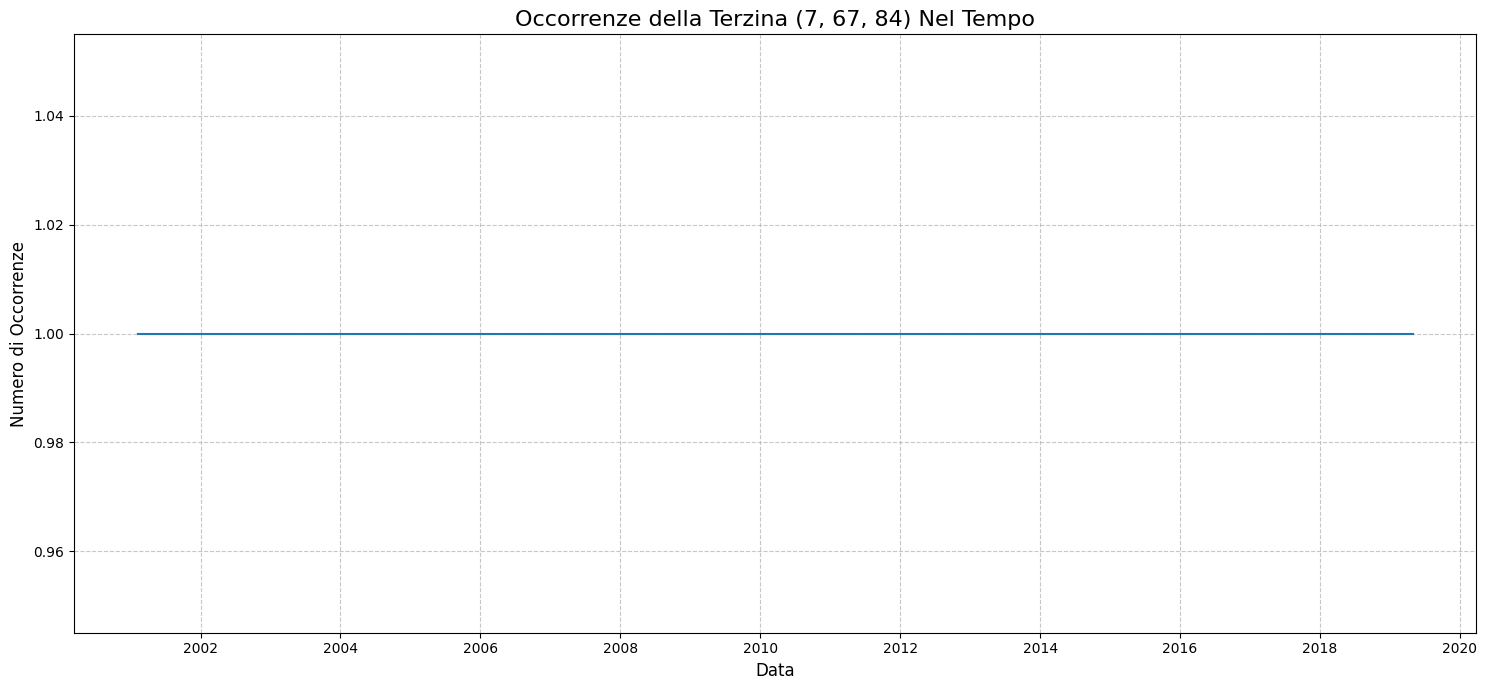

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Example: Analyze the temporal correlation of the most frequent global triplet
if not global_triplet_df.empty:
    most_frequent_triplet = global_triplet_df.iloc[0]['Terzina']
    print(f"Analisi delle occorrenze temporali per la terzina più frequente: {most_frequent_triplet}")

    # Filter the temporal_triplet_df for this specific triplet
    triplet_time_series = temporal_triplet_df[temporal_triplet_df['Terzina'] == most_frequent_triplet]

    # Group by date and count occurrences
    daily_occurrences = triplet_time_series.groupby('Data').size().reset_index(name='Occurrences')

    # Plot the occurrences over time
    plt.figure(figsize=(15, 7))
    sns.lineplot(x='Data', y='Occurrences', data=daily_occurrences)
    plt.title(f'Occorrenze della Terzina {most_frequent_triplet} Nel Tempo', fontsize=16)
    plt.xlabel('Data', fontsize=12)
    plt.ylabel('Numero di Occorrenze', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("Impossibile analizzare la correlazione temporale: nessuna terzina globale trovata.")

### Analisi Temporale per le Altre Terzine nella Top 10 Globale

Procediamo ora con la visualizzazione delle occorrenze nel tempo per le restanti terzine più frequenti a livello globale. Questo ci permetterà di confrontare i loro andamenti e identificare eventuali pattern temporali specifici per ciascuna.

Analisi delle occorrenze temporali per la terzina: (8, 32, 40)


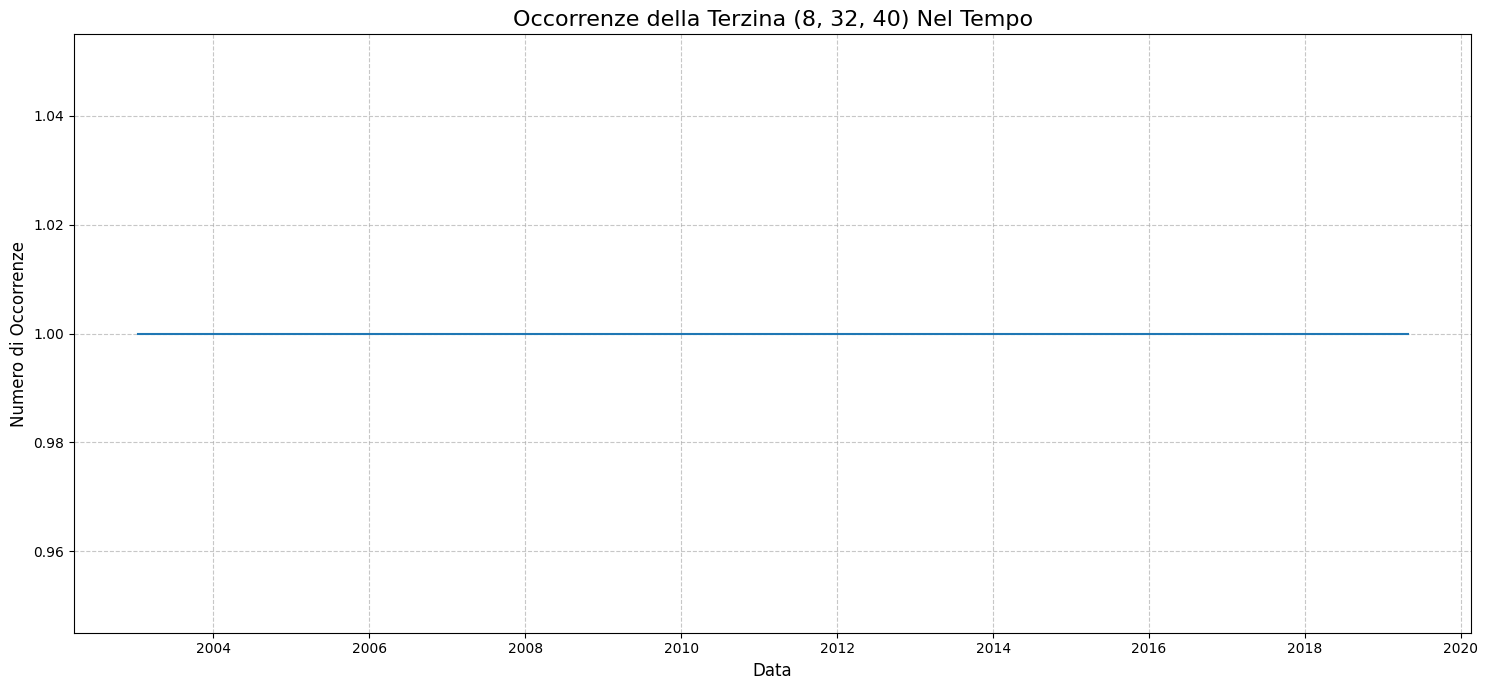

Analisi delle occorrenze temporali per la terzina: (10, 11, 44)


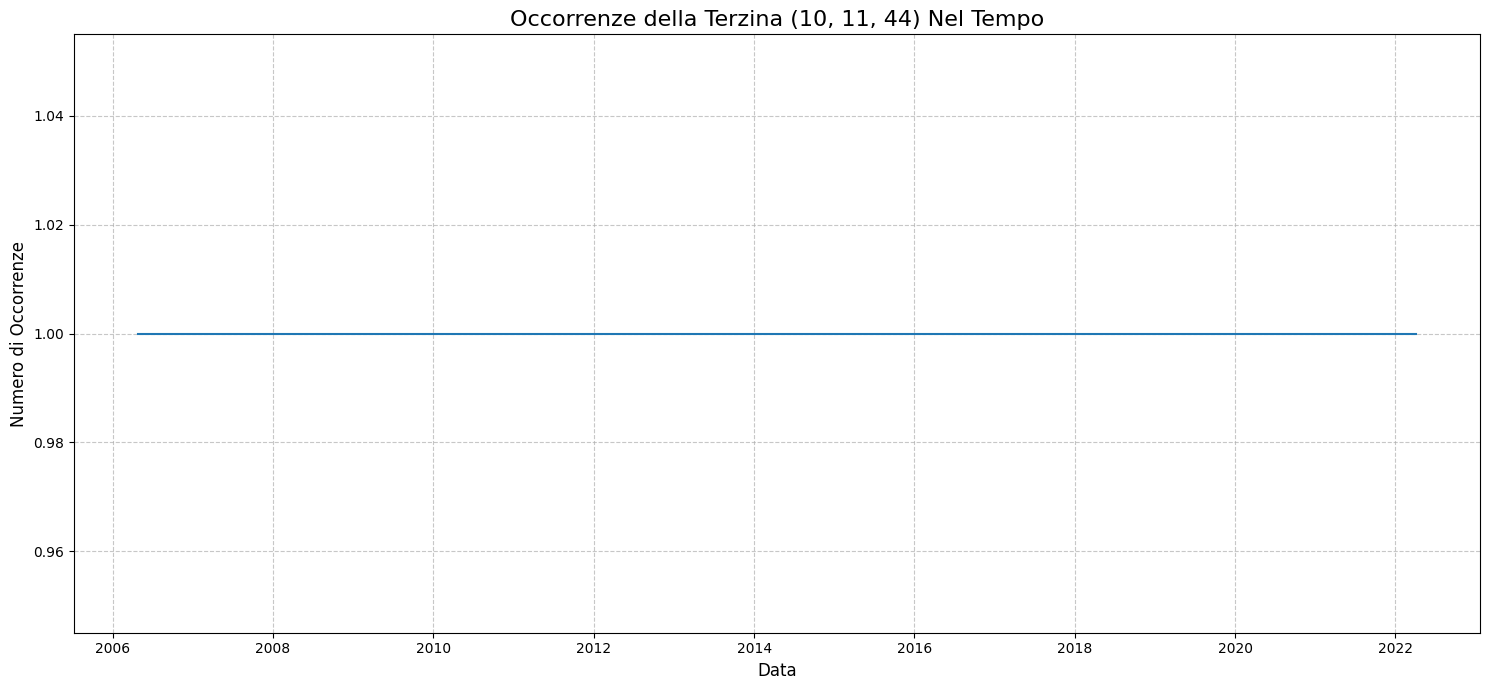

Analisi delle occorrenze temporali per la terzina: (10, 11, 65)


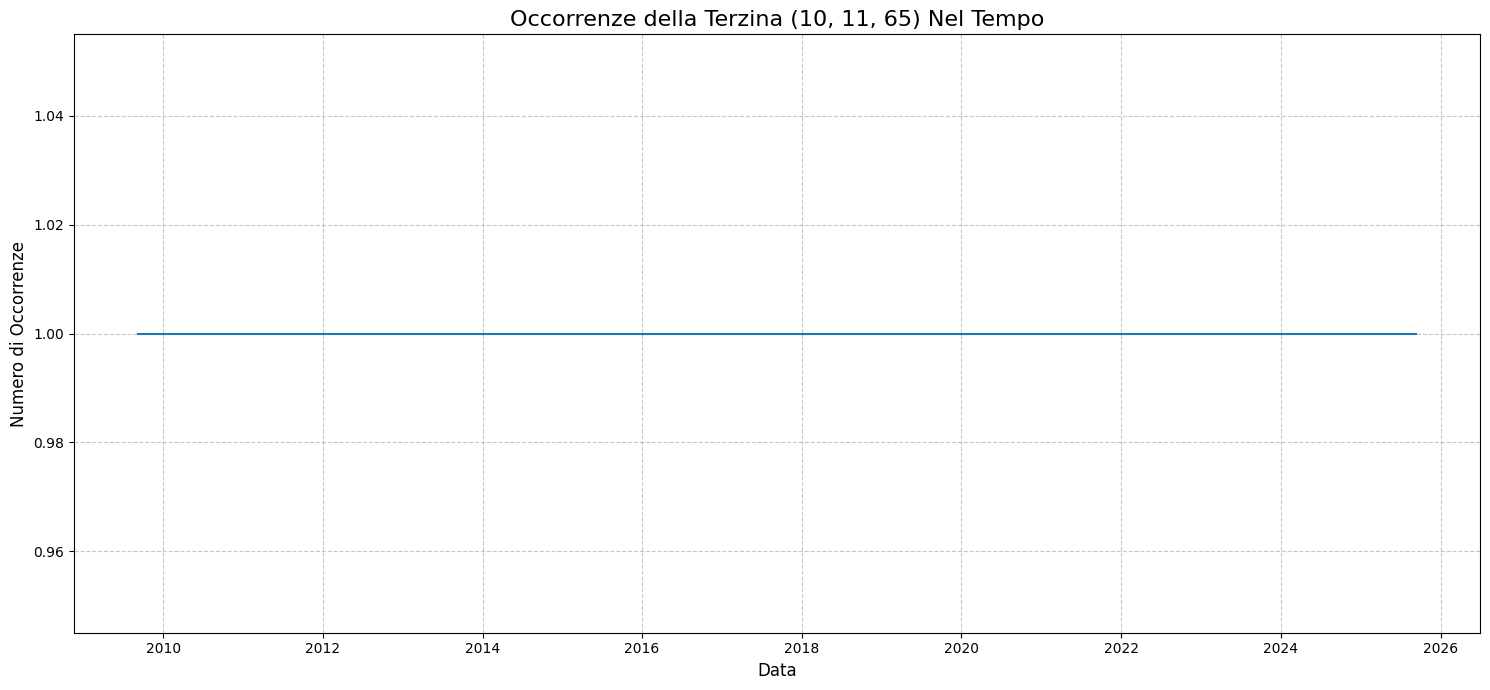

Analisi delle occorrenze temporali per la terzina: (27, 64, 89)


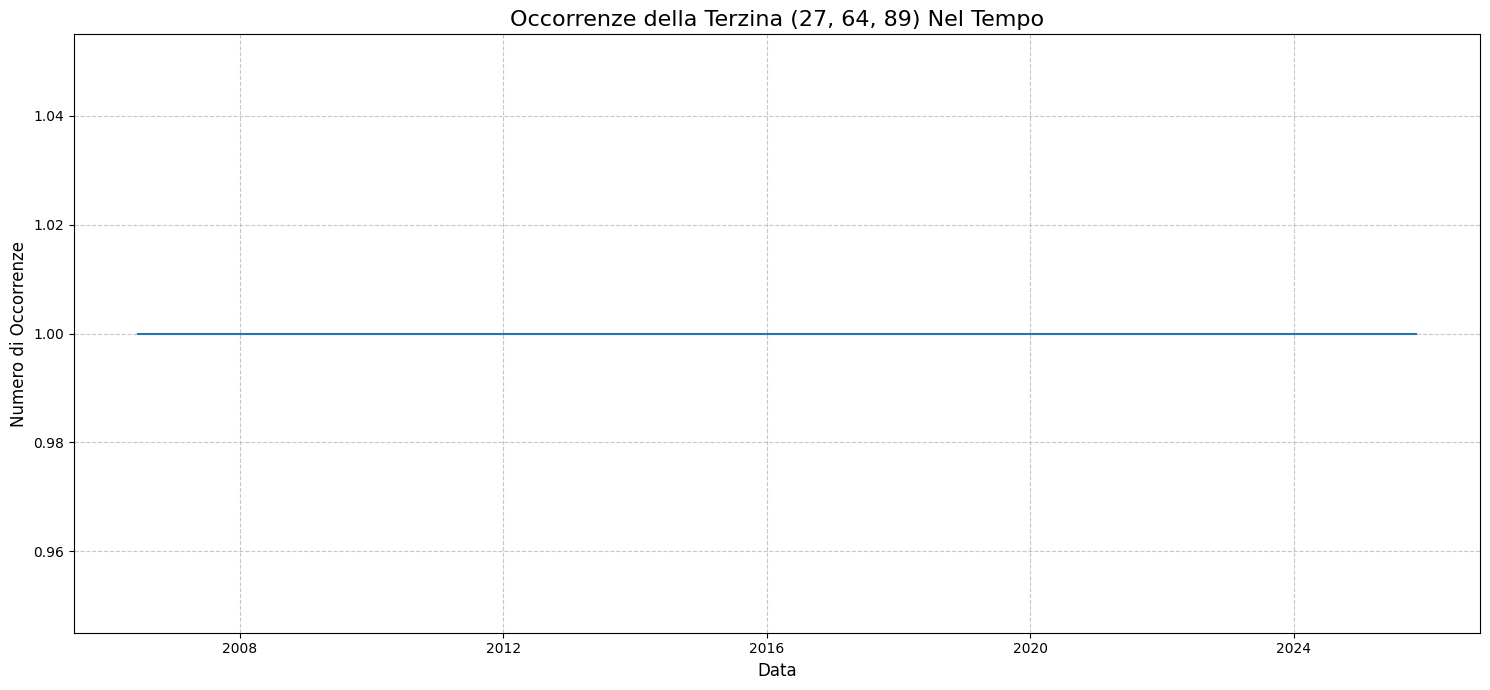

Analisi delle occorrenze temporali per la terzina: (18, 64, 78)


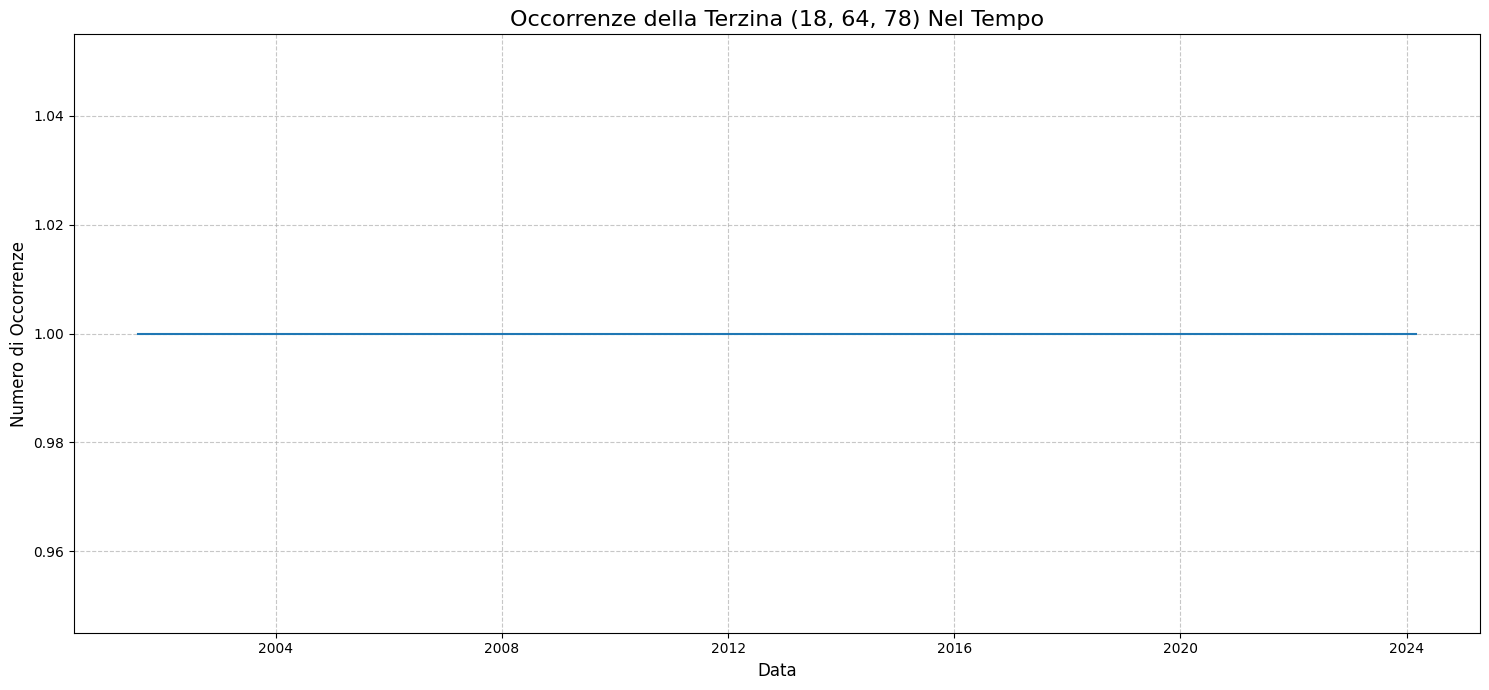

Analisi delle occorrenze temporali per la terzina: (1, 57, 69)


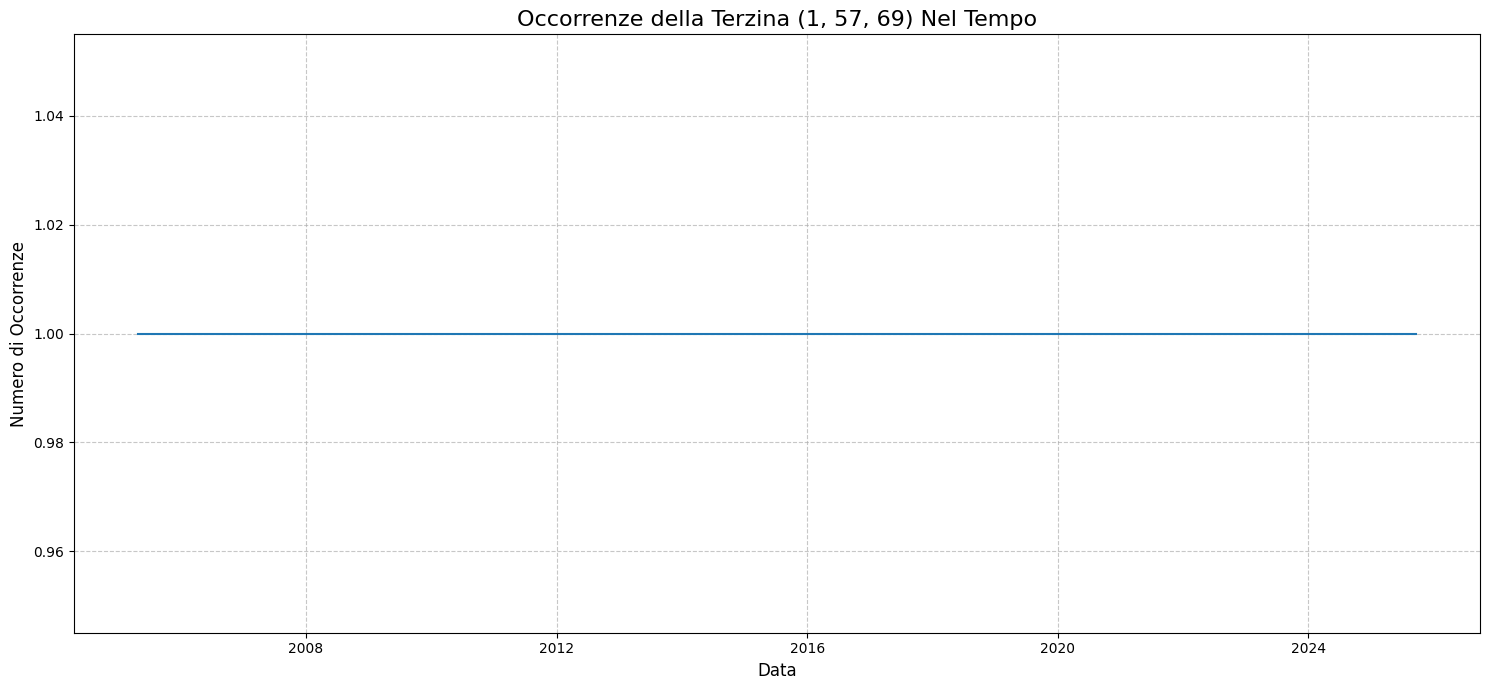

Analisi delle occorrenze temporali per la terzina: (20, 54, 90)


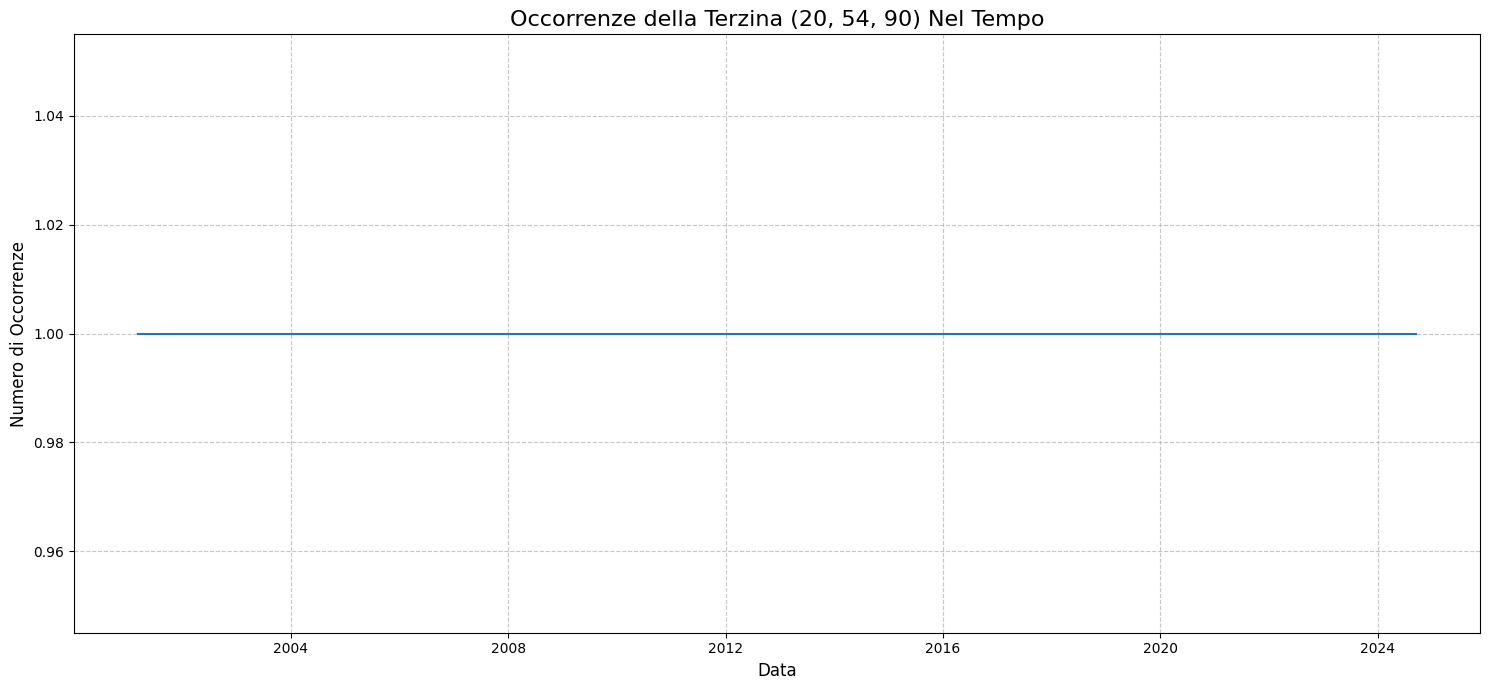

Analisi delle occorrenze temporali per la terzina: (5, 39, 57)


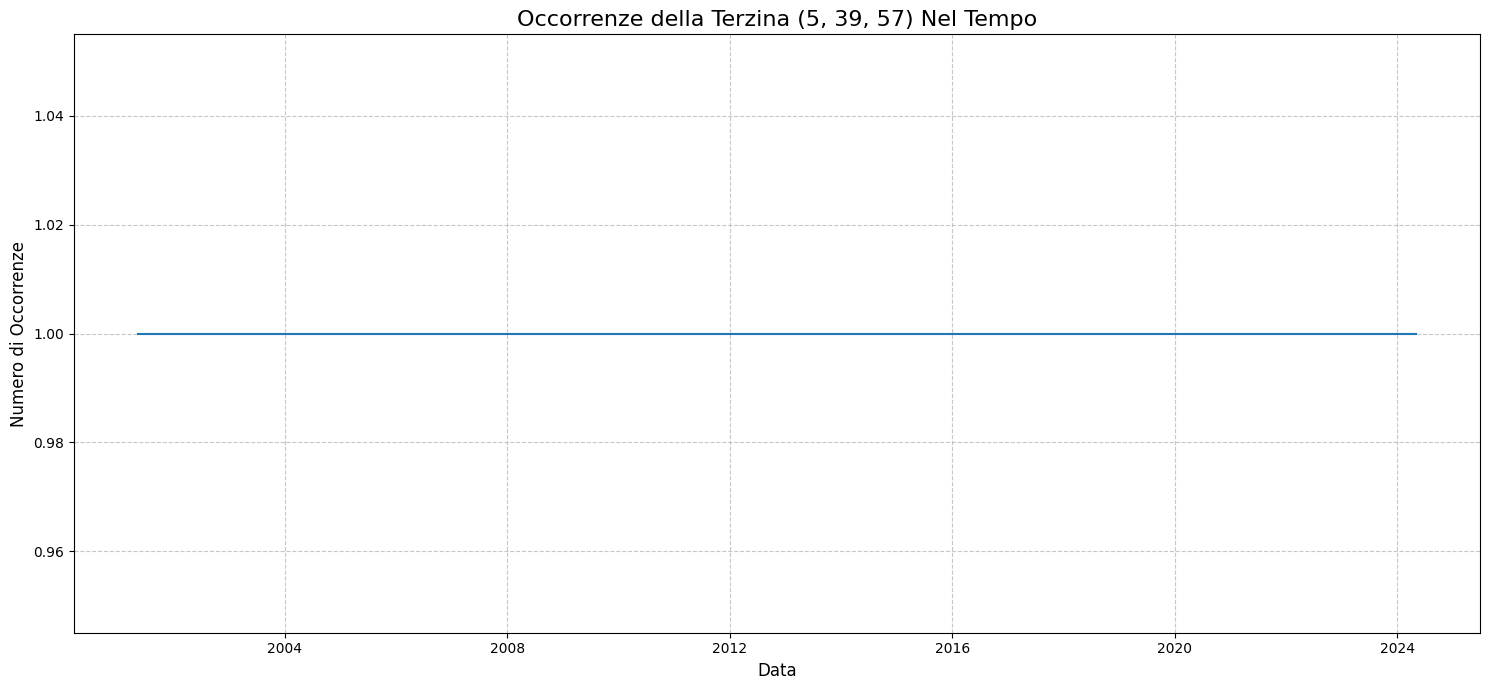

Analisi delle occorrenze temporali per la terzina: (61, 63, 66)


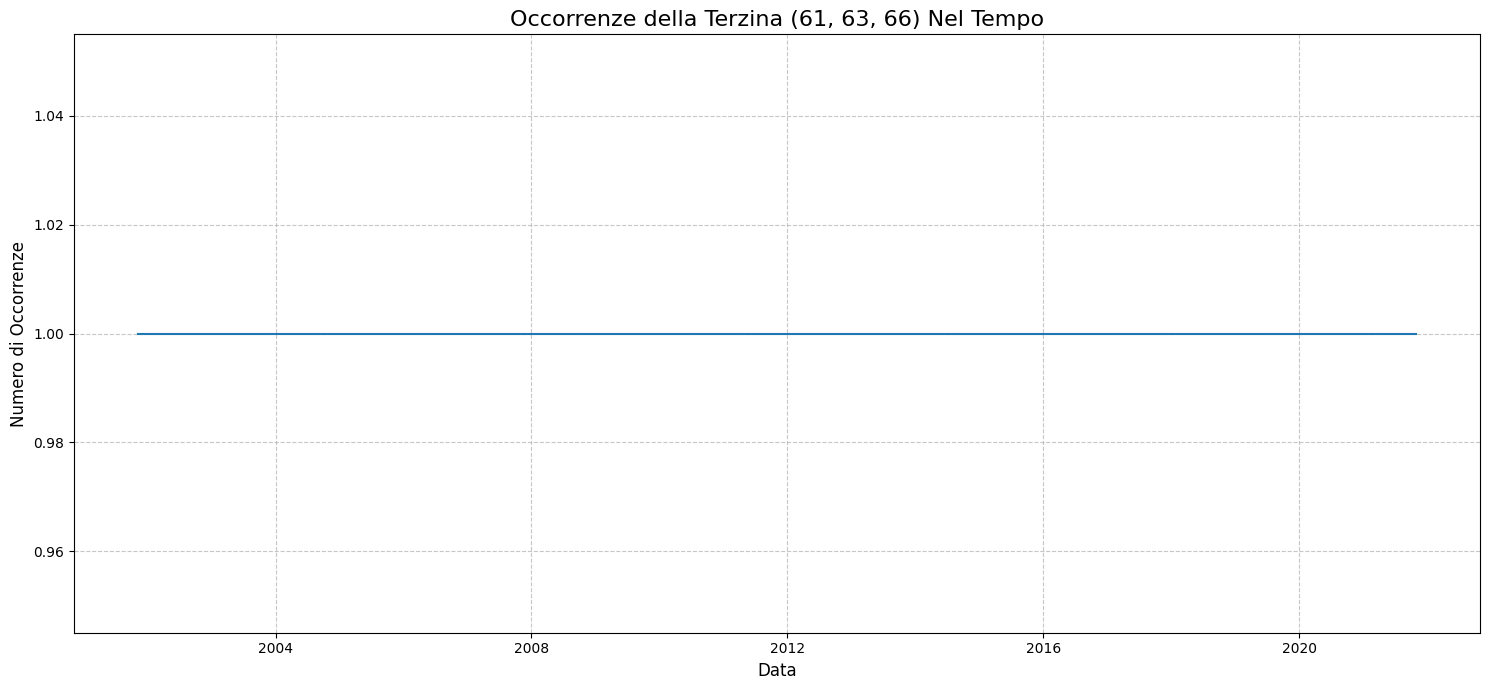

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Analizziamo le occorrenze temporali per le altre terzine nella top 10 globale
# Saltiamo la prima terzina perché è già stata analizzata nel blocco precedente

if not global_triplet_df.empty:
    for index, row in top_10_global_triplets.iloc[1:].iterrows(): # Inizia dal secondo elemento (indice 1)
        current_triplet = row['Terzina']
        print(f"Analisi delle occorrenze temporali per la terzina: {current_triplet}")

        # Filtra il temporal_triplet_df per questa specifica terzina
        triplet_time_series = temporal_triplet_df[temporal_triplet_df['Terzina'] == current_triplet]

        # Raggruppa per data e conta le occorrenze
        daily_occurrences = triplet_time_series.groupby('Data').size().reset_index(name='Occurrences')

        # Crea il grafico delle occorrenze nel tempo
        plt.figure(figsize=(15, 7))
        sns.lineplot(x='Data', y='Occurrences', data=daily_occurrences)
        plt.title(f'Occorrenze della Terzina {current_triplet} Nel Tempo', fontsize=16)
        plt.xlabel('Data', fontsize=12)
        plt.ylabel('Numero di Occorrenze', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
else:
    print("Impossibile analizzare la correlazione temporale: nessuna terzina globale trovata.")

### Distribuzione Temporale Comparata delle Top 10 Terzine Globali

Per un confronto diretto, visualizziamo le occorrenze nel tempo di tutte le 10 terzine più frequenti in un unico grafico. Questo ci permetterà di osservare come le loro frequenze cambiano e si relazionano tra loro nel corso degli anni.

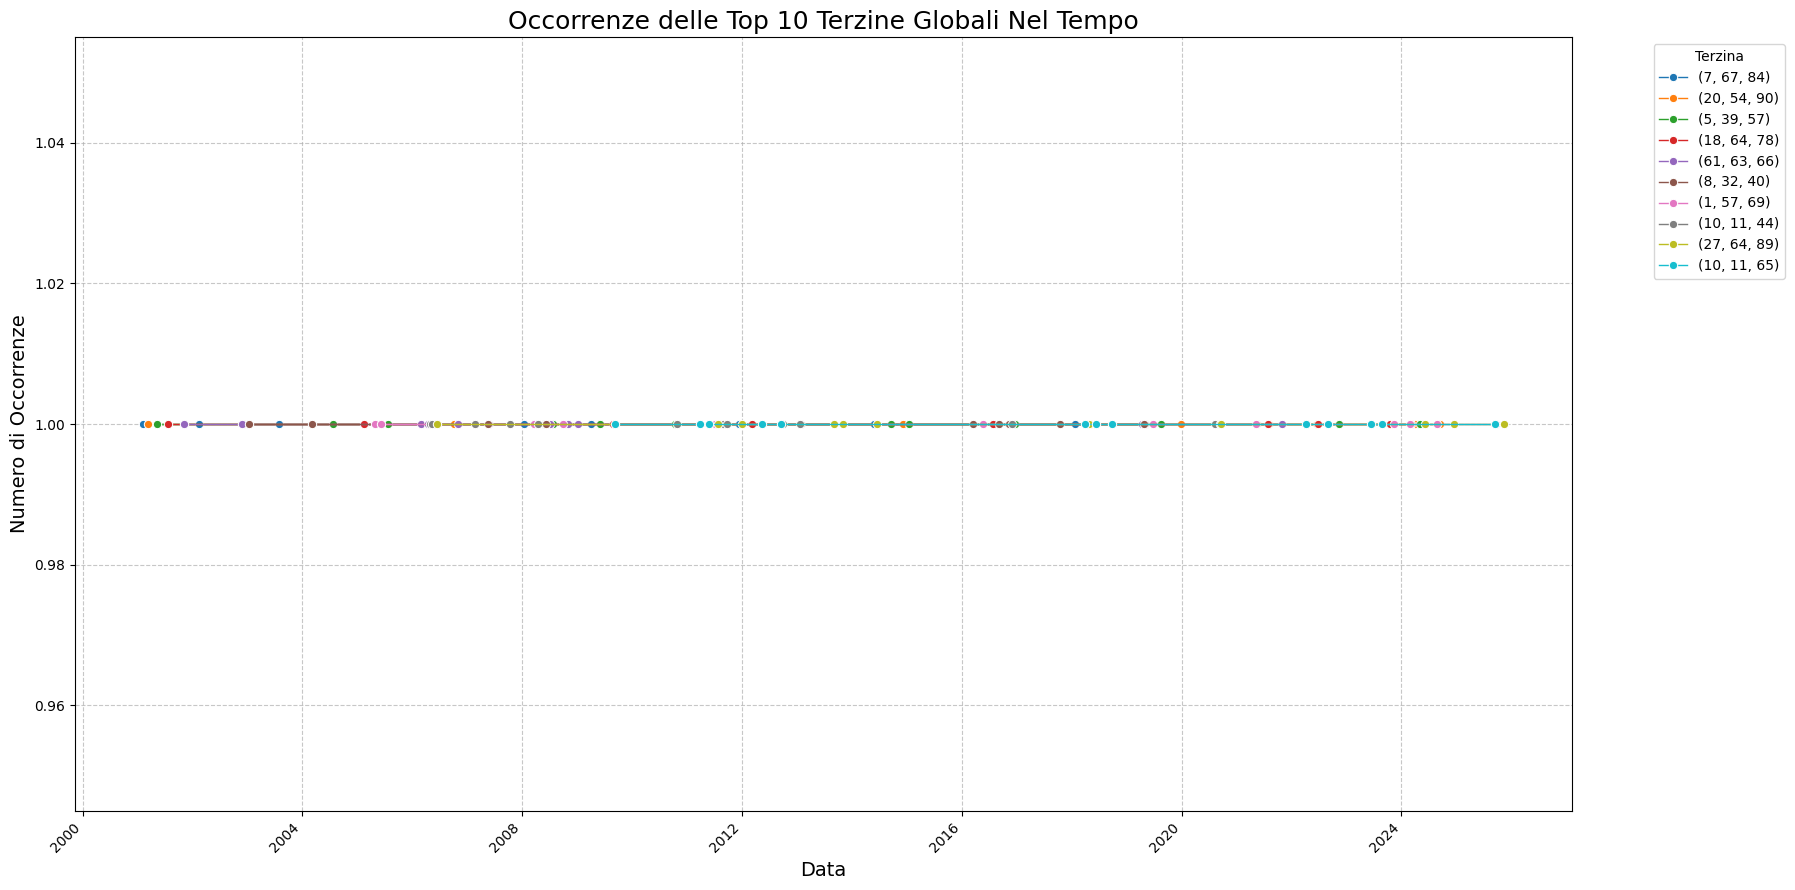

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

if not global_triplet_df.empty:
    # Estrai le terzine dalla top_10_global_triplets
    top_10_triplets_list = top_10_global_triplets['Terzina'].tolist()

    # Filtra il temporal_triplet_df per includere solo le occorrenze di queste terzine
    filtered_temporal_df = temporal_triplet_df[temporal_triplet_df['Terzina'].isin(top_10_triplets_list)].copy()

    # Raggruppa per data e terzina e conta le occorrenze
    # Convertiamo la tupla 'Terzina' in stringa per una migliore leggibilità nella legenda
    filtered_temporal_df['Terzina_Str'] = filtered_temporal_df['Terzina'].apply(lambda x: str(x))

    combined_daily_occurrences = filtered_temporal_df.groupby(['Data', 'Terzina_Str']).size().reset_index(name='Occurrences')

    plt.figure(figsize=(18, 9))
    sns.lineplot(x='Data', y='Occurrences', hue='Terzina_Str', data=combined_daily_occurrences, marker='o', linewidth=1)
    plt.title('Occorrenze delle Top 10 Terzine Globali Nel Tempo', fontsize=18)
    plt.xlabel('Data', fontsize=14)
    plt.ylabel('Numero di Occorrenze', fontsize=14)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(fontsize=10)
    plt.legend(title='Terzina', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("Impossibile creare il grafico combinato: nessuna terzina globale trovata.")